<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [5]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey_data.csv")

# Display the first few rows to understand the structure of the data
df.head()


'wget' is not recognized as an internal or external command,
operable program or batch file.


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



,DatabaseWantToWorkWith
1,PostgreSQL
2,Firebase Realtime Database
3,MongoDB
3,MySQL
3,PostgreSQL


,DatabaseWantToWorkWith
1,PostgreSQL
2,Firebase Realtime Database
3,MongoDB
3,MySQL
3,PostgreSQL


DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

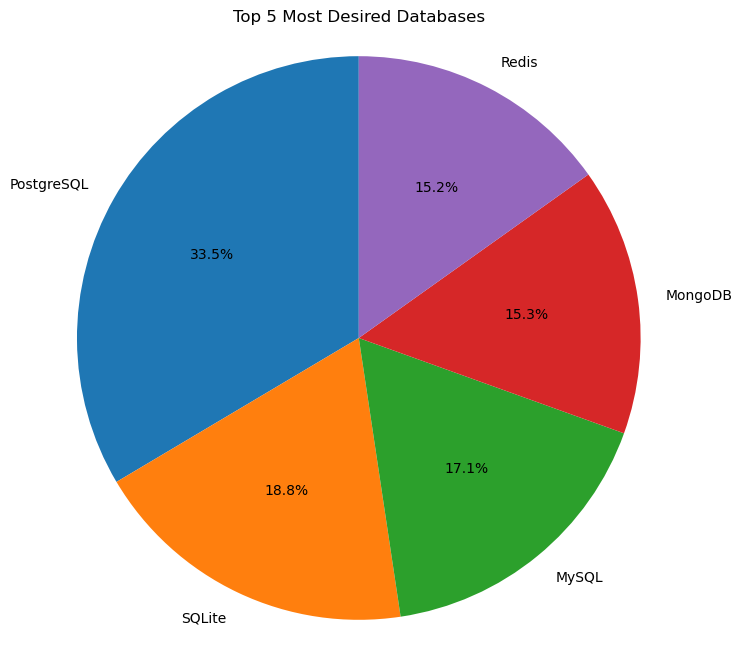

In [11]:
##Write your code here

df_pie = df[['DatabaseWantToWorkWith']].dropna()
df_pie['DatabaseWantToWorkWith'] = df_pie['DatabaseWantToWorkWith'].str.split(';')
df_pie_expanded = df_pie.explode('DatabaseWantToWorkWith')
display(df_pie_expanded.head())

df_pie_cleaned = df_pie_expanded.dropna()
display(df_pie_cleaned.head())

database_counts = df_pie_cleaned['DatabaseWantToWorkWith'].value_counts()
display(database_counts.head())

top_5_databases = database_counts.head(5)
display(top_5_databases)

plt.figure(figsize=(8, 8))
plt.pie(top_5_databases, labels=top_5_databases.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Most Desired Databases')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



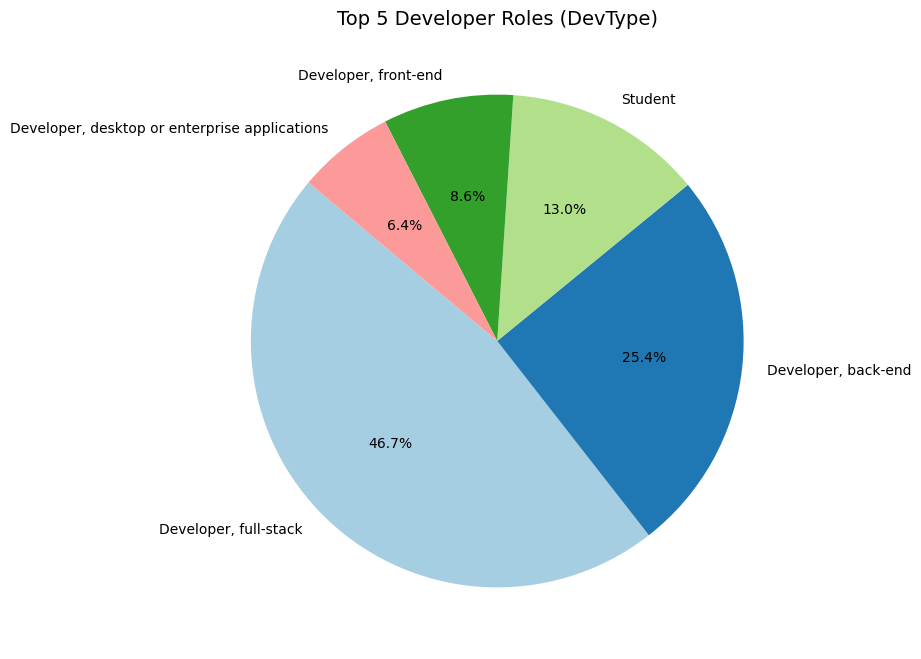

In [13]:
##Write your code here

# --- 1. Select relevant column and drop missing ---
df_dev = df[['DevType']].dropna()

# --- 2. Split multiple roles into rows ---
df_dev['DevType_list'] = df_dev['DevType'].str.split(';')
df_exploded = df_dev.explode('DevType_list')
df_exploded['DevType_list'] = df_exploded['DevType_list'].str.strip()

# --- 3. Count frequencies ---
dev_counts = df_exploded['DevType_list'].value_counts().head(5)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    dev_counts,
    labels=dev_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title("Top 5 Developer Roles (DevType)", fontsize=14)
plt.show()


##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



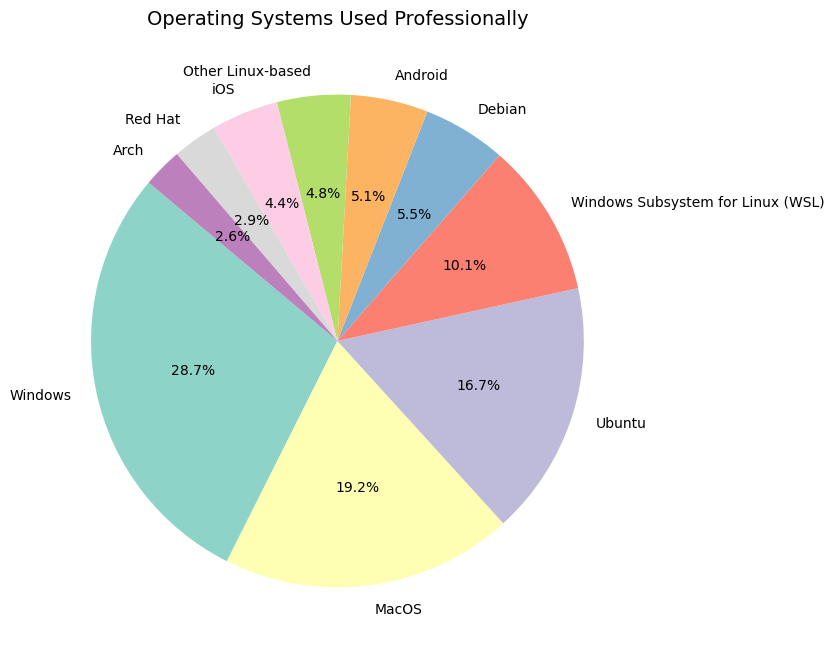

In [17]:
##Write your code here

df_os = df[['OpSysProfessional use']].dropna()

# --- 2. Split multiple OS entries into rows ---
df_os['OS_list'] = df_os['OpSysProfessional use'].str.split(';')
df_exploded = df_os.explode('OS_list')
df_exploded['OS_list'] = df_exploded['OS_list'].str.strip()

# --- 3. Count frequencies ---

os_counts = df_exploded['OS_list'].value_counts().head(10)


# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    os_counts,
    labels=os_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors
)

plt.title("Operating Systems Used Professionally", fontsize=14)
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



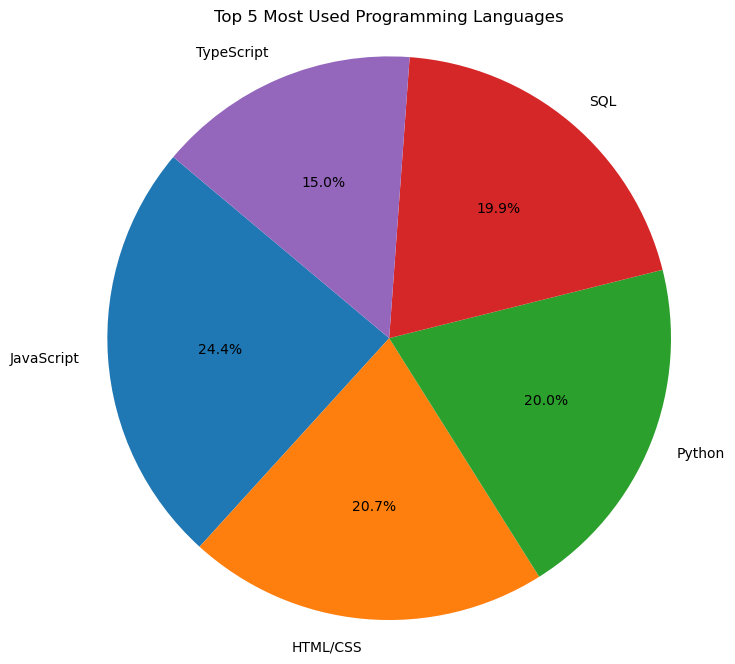

In [19]:
##Write your code here

df_languages_pie = df[['LanguageHaveWorkedWith']].dropna()
df_languages_pie['LanguageHaveWorkedWith'] = df_languages_pie['LanguageHaveWorkedWith'].str.split(';')
df_languages_pie_expanded = df_languages_pie.explode('LanguageHaveWorkedWith')

# Data Aggregation: Count the frequency of each language
language_counts = df_languages_pie_expanded['LanguageHaveWorkedWith'].value_counts()

# Top 5 Selection: Select the top 5 most frequent languages
top_5_languages = language_counts.head(5)

# Pie Chart Creation: Generate a pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_5_languages, labels=top_5_languages.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 5 Most Used Programming Languages')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



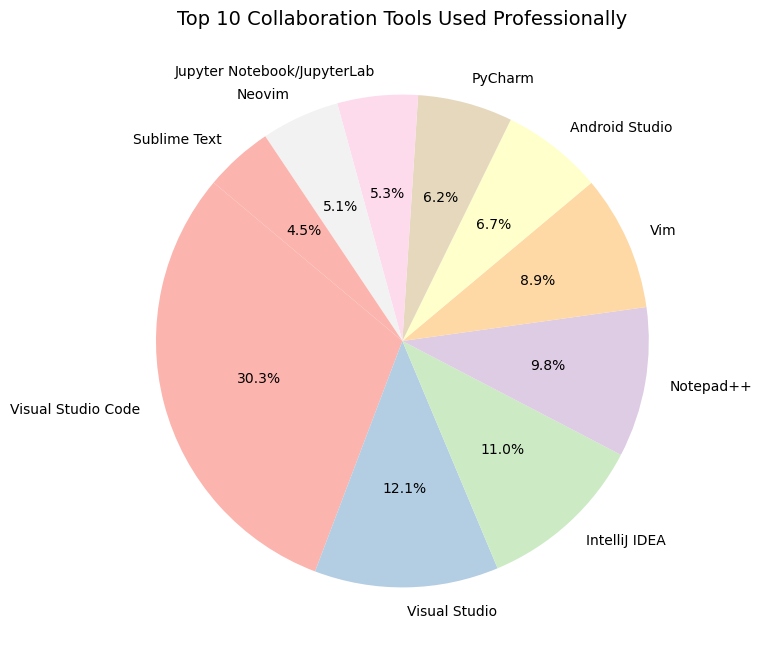

In [27]:
##Write your code here-

# --- 1. Select relevant column and drop missing ---
df_tools = df[['NEWCollabToolsHaveWorkedWith']].dropna()

# --- 2. Split multiple tools into rows ---
df_tools['Tool_list'] = df_tools['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_exploded = df_tools.explode('Tool_list')
df_exploded['Tool_list'] = df_exploded['Tool_list'].str.strip()

# --- 3. Count frequencies (Top 10 tools) ---
tool_counts = df_exploded['Tool_list'].value_counts().head(10)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    tool_counts,
    labels=tool_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors
)

plt.title("Top 10 Collaboration Tools Used Professionally", fontsize=14)
plt.show()


### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



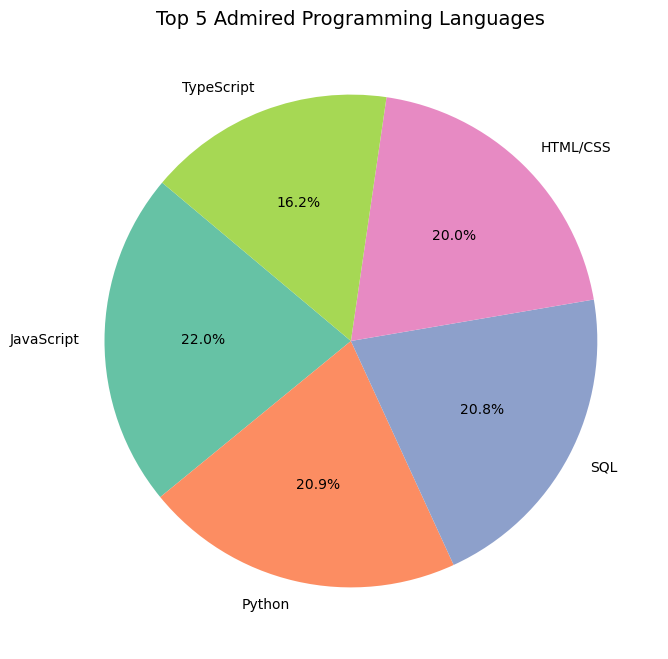

In [29]:
##Write your code here


# --- 1. Select relevant column and drop missing ---
df_lang = df[['LanguageAdmired']].dropna()

# --- 2. Split multiple admired languages into rows ---
df_lang['Language_list'] = df_lang['LanguageAdmired'].str.split(';')
df_exploded = df_lang.explode('Language_list')
df_exploded['Language_list'] = df_exploded['Language_list'].str.strip()

# --- 3. Count frequencies (Top 5) ---
lang_counts = df_exploded['Language_list'].value_counts().head(5)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    lang_counts,
    labels=lang_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set2.colors
)

plt.title("Top 5 Admired Programming Languages", fontsize=14)
plt.show()


##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



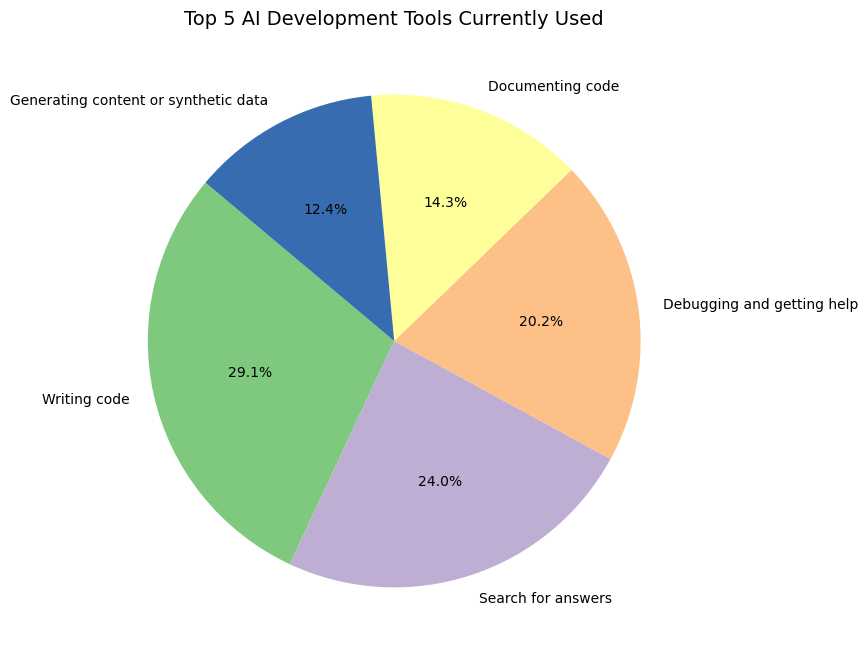

In [31]:
##Write your code here



# --- 1. Select relevant column and drop missing ---
df_ai = df[['AIToolCurrently Using']].dropna()

# --- 2. Split multiple tools into rows ---
df_ai['AITool_list'] = df_ai['AIToolCurrently Using'].str.split(';')
df_exploded = df_ai.explode('AITool_list')
df_exploded['AITool_list'] = df_exploded['AITool_list'].str.strip()

# --- 3. Count frequencies (Top 5 tools) ---
ai_counts = df_exploded['AITool_list'].value_counts().head(5)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    ai_counts,
    labels=ai_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Accent.colors
)

plt.title("Top 5 AI Development Tools Currently Used", fontsize=14)
plt.show()


##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



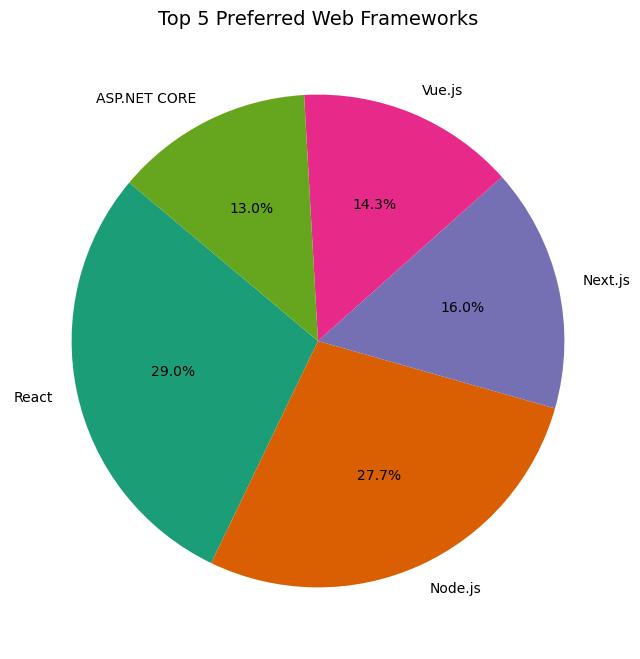

In [33]:
##Write your code here


# --- 1. Select relevant column and drop missing ---
df_web = df[['WebframeWantToWorkWith']].dropna()

# --- 2. Split multiple frameworks into rows ---
df_web['Framework_list'] = df_web['WebframeWantToWorkWith'].str.split(';')
df_exploded = df_web.explode('Framework_list')
df_exploded['Framework_list'] = df_exploded['Framework_list'].str.strip()

# --- 3. Count frequencies (Top 5 frameworks) ---
framework_counts = df_exploded['Framework_list'].value_counts().head(5)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    framework_counts,
    labels=framework_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Dark2.colors
)

plt.title("Top 5 Preferred Web Frameworks", fontsize=14)
plt.show()


##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



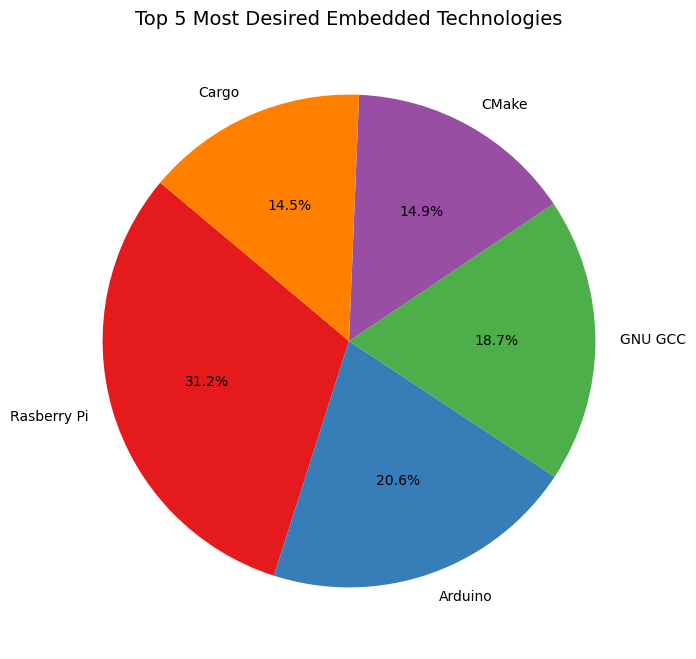

In [35]:
##Write your code here

# --- 1. Select relevant column and drop missing ---
df_embedded = df[['EmbeddedWantToWorkWith']].dropna()

# --- 2. Split multiple technologies into rows ---
df_embedded['Embedded_list'] = df_embedded['EmbeddedWantToWorkWith'].str.split(';')
df_exploded = df_embedded.explode('Embedded_list')
df_exploded['Embedded_list'] = df_exploded['Embedded_list'].str.strip()

# --- 3. Count frequencies (Top 5) ---
embedded_counts = df_exploded['Embedded_list'].value_counts().head(5)

# --- 4. Plot Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    embedded_counts,
    labels=embedded_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set1.colors
)

plt.title("Top 5 Most Desired Embedded Technologies", fontsize=14)
plt.show()


### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
